# NHS Neurodevelopmental Assessment Pathway — Discrete-Event Simulation

## 1. Model background

This notebook simulates the **NHS neurodevelopmental (autism/ADHD) assessment pathway** as a
**discrete-event simulation (DES)**: referrals arrive over time, compete for a shared pool of
clinician hours, and flow through triage → assessment → diagnosis → support until they leave the
system.

**The problem we are solving.** These services carry large, growing **waiting lists (the NHS
"Patient Tracking List", or PTL)**. Demand (referrals) outstrips capacity (clinician hours), so
patients breach the NHS **18-week** and **52-week** waiting-time standards. Managers need to know:

- How big will the backlog get, and how long are people really waiting?
- What level of capacity (clinician hours) is needed to hold or reduce the backlog?
- Which policy levers (more capacity, higher administrative removal, etc.) actually move the
  waiting-time standards — and by how much?

We answer these with **three independent runs** on the same underlying engine:

| Run | Purpose | What it produces |
| --- | --- | --- |
| **Run 1** | *Calibration* | Grows the horizon until the model's PTL matches the provider's target → the **Matching Period `T*`** |
| **Run 2** | *Stochastic baseline* | Repeats the As-Is scenario over many random seeds → KPI means with **95% confidence intervals** |
| **Run 3** | *Policy analysis* | Runs to `T*`, applies a policy change (e.g. double capacity), then measures **backlog decay** and waiting-time standards |

## Contents

1. [Model background](#1.-Model-background)
2. [Patient pathway](#2.-Patient-pathway)
3. [Setup](#3.-Setup)
4. [Warm-up sensitivity check](#4.-Warm-up-sensitivity-check)
5. [KPI dictionary](#5.-KPI-dictionary)
6. [Run 1: calibration to find the Matching Period (T*)](#6.-Run-1:-calibration-to-find-the-Matching-Period-(T*))
7. [Run 2: stochastic baseline](#7.-Run-2:-stochastic-baseline)
8. [Run 3: increased-capacity policy](#8.-Run-3:-increased-capacity-policy)
9. [Run 3 grid: capacity vs decay](#9.-Run-3-grid:-capacity-vs-decay)
10. [Run 3 grid: heatmaps](#10.-Run-3-grid:-heatmaps)
11. [Run 3: administrative-removal policy](#11.-Run-3:-administrative-removal-policy)
12. [Run 3: plots from the grid](#12.-Run-3:-plots-from-the-grid)
13. [Policy tests — double capacity vs double admin removal](#13.-Policy-tests-—-double-capacity-vs-double-admin-removal)


## 2. Patient pathway

Each referral is one patient moving through the stages below. The diagram intentionally omits
parameter values because they can change between scenarios. The **RTT clock** (the NHS waiting-time
clock) starts at an accepted referral and stops when the patient reaches a definitive outcome.
Anyone whose clock has **not** stopped at the reporting horizon is counted on the **waiting list
(PTL)**.

![NHS neurodevelopmental assessment pathway](figures/nhs-neurodevelopmental-pathway.png)

**Reading the diagram**

- **Triage** and **admin review** remove patients early (their clocks are nullified / stopped).
- The **assessment** stage is the capacity bottleneck: every appointment draws on the same shared
  weekday clinician-hour pool, so this is where queues (and the backlog) build up.
- After a positive **diagnosis**, patients split into a quick **virtual support** exit or a longer
  **clinical workshop** group before finishing treatment.

## 3. Setup

The next four cells prepare everything the runs need:

1. **Working directory** — move up to the project root so `des` imports resolve.
2. **Imports** — numerical/plotting libraries plus the DES engine (`Experiment`, `Audit`,
   `AutismPathwaySystem`, the `run1`/`run2`/`run3` framework, and `compute_kpis`).
3. **Model parameters** — arrival rate, triage/removal/diagnosis probabilities, assessment and
   workshop settings, capacity, and the simulation time horizons. `NOTEBOOK_EXPERIMENT_PARAMETERS`
   bundles these so every `Experiment` below uses *exactly* the same inputs.
4. **`simulation_run(...)`** — a helper that runs a warm-up followed by a KPI-collection window in
   one continuous simulation and returns the patient table, capacity ledger, and KPI summary.

In [1]:
import os
import sys
from pathlib import Path


def find_project_root(start: Path | None = None) -> Path:
    """Locate repo root (des/ package + demo.ipynb), not ~/Desktop/des.py."""
    path = Path(start or Path.cwd()).resolve()
    candidates = [path, *path.parents]
    if path.is_dir():
        candidates.extend(
            child for child in path.iterdir()
            if child.is_dir() and (child / "des" / "__init__.py").is_file()
        )
    for candidate in candidates:
        if (candidate / "des" / "__init__.py").is_file() and (candidate / "demo.ipynb").is_file():
            return candidate
    raise RuntimeError("Could not find project root (expected des/__init__.py and demo.ipynb)")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)


/home/guled/Desktop/discrete_event_adhd_sim


In [2]:

from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import simpy
from joblib import Parallel, delayed

from des.audit import Audit
from des.experiment import Experiment
from des.kpi import compute_kpis
from des.runs.run import run1, run2, run3
from des.system import AutismPathwaySystem
from des.trace import disable_trace, enable_trace

In [3]:
"""Global model parameters, time horizons, and scenario presets."""

from __future__ import annotations

from typing import Any, Dict

TRACE = False

REFERRALS_PER_DAY = 1.89

# Model parameters — simulation time horizons (calendar days, all 7 days of the week)
#   warm-up period              — system runs, KPIs are NOT collected
#   results collection period   — KPIs collected after warm-up
# Matching_Period / policy decay horizons live in configs/*_run.json (des.runs).
WARM_UP_PERIOD = 0
DEFAULT_RESULTS_COLLECTION_PERIOD = 365 * 5

# Backward-compatible aliases used by Audit defaults
WARMUP_DAYS = WARM_UP_PERIOD
COLLECTION_DAYS = DEFAULT_RESULTS_COLLECTION_PERIOD

IAT_WEEKDAY = 1 / REFERRALS_PER_DAY

PCT_REFERRAL_REJECTED = 0.369
PCT_ADMIN_REMOVAL = 0.10

ASSESSMENT_APPOINTMENT_COUNTS = [2, 3, 4, 5]
ASSESSMENT_APPOINTMENT_PROBS = [0.40, 0.30, 0.20, 0.10]
ASSESSMENT_GAP_DAYS = 7

DURATION_ASSESSMENT = [2.0, 2.5, 3.0]
DURATION_WORKSHOP_SESSION = [2, 3, 4]

PCT_DIAGNOSIS = 0.75
PCT_VIRTUAL_SUPPORT = 0.30

WORKSHOP_GROUP_SIZE = 8
WORKSHOP_NUM_SESSIONS = 6
WORKSHOP_SESSION_INTERVAL_WEEKS = 1
WORKSHOP_MAX_WAIT_DAYS = 28

# One shared weekday pool for assessment and post-diagnosis clinical support.
WORKFORCE_HOURS_PER_DAY = 7
WORKFORCE_HOURS_WORKSHOP_SESSION = 2.0

N_STREAMS = 15
DEFAULT_RND_SET = 42
N_REP = 5

# Explicit parameters passed to every Experiment in this notebook.
# This prevents Experiment from silently falling back to des.config defaults.
NOTEBOOK_EXPERIMENT_PARAMETERS = {
    "iat": IAT_WEEKDAY,
    "pct_referral_rejected": PCT_REFERRAL_REJECTED,
    "pct_admin_removal": PCT_ADMIN_REMOVAL,
    "assessment_appointment_counts": ASSESSMENT_APPOINTMENT_COUNTS,
    "assessment_appointment_probs": ASSESSMENT_APPOINTMENT_PROBS,
    "assessment_gap_days": ASSESSMENT_GAP_DAYS,
    "duration_assessment": DURATION_ASSESSMENT,
    "pct_diagnosis": PCT_DIAGNOSIS,
    "pct_virtual_support": PCT_VIRTUAL_SUPPORT,
    "workshop_group_size": WORKSHOP_GROUP_SIZE,
    "workshop_num_sessions": WORKSHOP_NUM_SESSIONS,
    "workshop_session_interval_weeks": WORKSHOP_SESSION_INTERVAL_WEEKS,
    "workshop_max_wait_days": WORKSHOP_MAX_WAIT_DAYS,
    "duration_workshop_session": DURATION_WORKSHOP_SESSION,
    "workforce_hours_workshop_session": WORKFORCE_HOURS_WORKSHOP_SESSION,
    "workforce_hours_per_day": WORKFORCE_HOURS_PER_DAY,
}


In [4]:
def simulation_run(
    experiment: Experiment,
    rep: int,
    run_length: int,
    warm_up: int,
) -> tuple[Any, Any, Any, Any]:
    """Run warm-up followed by KPI collection in one continuous simulation."""
    if experiment.use_fixed_seed:
        experiment.set_random_no_set(rep)

    collection_period = run_length - warm_up
    if collection_period <= 0:
        raise ValueError("run_length must be greater than warm_up")

    audit = experiment.audit
    # KPI window: [warm_up, warm_up + collection_period).
    audit.reset(warmup_days=warm_up, collection_days=collection_period)
    audit.monitoring = True

    env = simpy.Environment()
    system = AutismPathwaySystem(env, experiment)
    env.process(system.run())
    env.run(until=run_length)

    patients_pd = audit.finalize()
    capacity_pd = pd.DataFrame(audit.capacity_days)
    patient_flow = experiment.to_kwargs()

    result = compute_kpis(
        patients_pd,
        audit.window,
        experiment,
        system,
        audit.capacity_days,
    )

    return patients_pd, capacity_pd, patient_flow, result

## 4. Warm-up sensitivity check

Before calibrating, we sanity-check the effect of a **warm-up period** — time we simulate but do
*not* collect KPIs over, so the system reaches a realistic loaded state before measurement.

- **Scenario 1** — no warm-up, then 5 years of KPI collection.
- **Scenario 2** — a 5-year warm-up, then a separate 5-year KPI collection window.

Comparing the two shows how much the starting-from-empty transient inflates or deflates the KPIs,
which motivates the horizon choices used in the runs below.

In [5]:
# Scenario 1 — no warm-up, followed by five years of KPI collection.
DAYS_PER_YEAR = 365
COLLECTION_PERIOD = 5 * DAYS_PER_YEAR

warm_up_0 = 0
run_length_0 = warm_up_0 + COLLECTION_PERIOD  # 5 years total
experiment_0 = Experiment(
    audit=Audit(),
    random_number_set=DEFAULT_RND_SET,
    n_streams=N_STREAMS,
    use_fixed_seed=True,
    scenario_name="0-year warm-up",
    **NOTEBOOK_EXPERIMENT_PARAMETERS,
)

patients_0, capacity_0, model_params_0, result_0 = simulation_run(
    experiment_0,
    rep=0,
    run_length=run_length_0,
    warm_up=warm_up_0,
)

pd.DataFrame(
    [{
        "warm_up_years": 0,
        "collection_years": 5,
        "total_run_years": 5,
        "kpi_window_start_day": warm_up_0,
        "kpi_window_end_day": run_length_0,
        "collection_cohort_referrals": result_0.summary["referrals"],
        "nhs_ptl_at_end": result_0.summary["waiting_list_size_all_in_system"],
    }]
)

,warm_up_years,collection_years,total_run_years,kpi_window_start_day,kpi_window_end_day,collection_cohort_referrals,nhs_ptl_at_end
0,0,5,5,0,1825,2726,821


In [6]:
result_0.summary

{'referrals': 2726,
 'referrals_accepted': 1765,
 'referrals_rejected': 961,
 'rtt_clocks_started': 1765,
 'rtt_clocks_nullified': 961,
 'rtt_completed_pathways': 944,
 'cohort_incomplete_pathways': 821,
 'rtt_completed_stop_treatment': 611,
 'rtt_completed_stop_not_treat': 166,
 'rtt_completed_stop_admin': 167,
 'cohort_under_18_weeks': 112,
 'cohort_over_18_weeks': 709,
 'cohort_under_52_weeks': 314,
 'cohort_over_52_weeks': 507,
 'cohort_under_18_weeks_pct': 13.64190012180268,
 'cohort_over_18_weeks_pct': 86.35809987819732,
 'cohort_under_52_weeks_pct': 38.24604141291108,
 'cohort_over_52_weeks_pct': 61.75395858708892,
 'ptl_size': 821,
 'ptl_under_18_weeks': 112,
 'ptl_over_18_weeks': 709,
 'ptl_under_52_weeks': 314,
 'ptl_over_52_weeks': 507,
 'ptl_under_18_weeks_pct': 13.64190012180268,
 'ptl_over_18_weeks_pct': 86.35809987819732,
 'ptl_under_52_weeks_pct': 38.24604141291108,
 'ptl_over_52_weeks_pct': 61.75395858708892,
 'admin_removals': 167,
 'assessments_completed_in_window': 

In [7]:
# Scenario 2 — five-year warm-up, then a separate five-year KPI collection period.
warm_up_5 = 5 * DAYS_PER_YEAR
run_length_5 = warm_up_5 + COLLECTION_PERIOD  # 10 years total
experiment_5 = Experiment(
    audit=Audit(),
    random_number_set=DEFAULT_RND_SET,
    n_streams=N_STREAMS,
    use_fixed_seed=True,
    scenario_name="5-year warm-up",
    **NOTEBOOK_EXPERIMENT_PARAMETERS,
)

patients_5, capacity_5, model_params_5, result_5 = simulation_run(
    experiment_5,
    rep=0,
    run_length=run_length_5,
    warm_up=warm_up_5,
)

pd.DataFrame(
    [{
        "warm_up_years": 5,
        "collection_years": 5,
        "total_run_years": 10,
        "kpi_window_start_day": warm_up_5,
        "kpi_window_end_day": run_length_5,
        "collection_cohort_referrals": result_5.summary["referrals"],
        "nhs_ptl_at_end": result_5.summary["waiting_list_size_all_in_system"],
    }]
)

#

,warm_up_years,collection_years,total_run_years,kpi_window_start_day,kpi_window_end_day,collection_cohort_referrals,nhs_ptl_at_end
0,5,5,10,1825,3650,2748,1581


In [8]:
result_5.summary

{'referrals': 2748,
 'referrals_accepted': 1738,
 'referrals_rejected': 1010,
 'rtt_clocks_started': 1738,
 'rtt_clocks_nullified': 1010,
 'rtt_completed_pathways': 966,
 'cohort_incomplete_pathways': 1557,
 'rtt_completed_stop_treatment': 592,
 'rtt_completed_stop_not_treat': 193,
 'rtt_completed_stop_admin': 181,
 'cohort_under_18_weeks': 99,
 'cohort_over_18_weeks': 1458,
 'cohort_under_52_weeks': 289,
 'cohort_over_52_weeks': 1268,
 'cohort_under_18_weeks_pct': 6.358381502890174,
 'cohort_over_18_weeks_pct': 93.64161849710983,
 'cohort_under_52_weeks_pct': 18.561335902376364,
 'cohort_over_52_weeks_pct': 81.43866409762363,
 'ptl_size': 1581,
 'ptl_under_18_weeks': 99,
 'ptl_over_18_weeks': 1482,
 'ptl_under_52_weeks': 289,
 'ptl_over_52_weeks': 1292,
 'ptl_under_18_weeks_pct': 6.261859582542694,
 'ptl_over_18_weeks_pct': 93.7381404174573,
 'ptl_under_52_weeks_pct': 18.27956989247312,
 'ptl_over_52_weeks_pct': 81.72043010752688,
 'admin_removals': 181,
 'assessments_completed_in_win

## 5. KPI dictionary

Every run below reports the same family of KPIs. This section defines **what each KPI is**, **how
the model records it**, and **how it is calculated**, so the tables in Runs 1–3 can be read without
guessing.

### 5.1 How the model records events

As each patient moves through the pathway, the simulation writes one row per patient to the
**audit**, timestamping each stage. It also keeps a **daily capacity ledger** for the shared
weekday clinician-hour pool.

**Per-patient record (key fields)**

| Field | Meaning |
| --- | --- |
| `arrival_time` | Day the referral enters (candidate RTT clock start) |
| `triage_outcome` | `accepted` / `rejected` |
| `admin_removal` | `True` if removed at administrative review |
| `assessment_start` | Day of the first assessment appointment |
| `assessment_completion` | Day the final assessment appointment finishes |
| `diagnosis` | `True` / `False` |
| `support_type` | `virtual` / `clinical` |
| `exit_time`, `exit_route` | When and why the patient left (`referral_rejected`, `admin_removal`, `no_diagnosis`, `virtual_support`, `workshop_complete`) |
| `rtt_pathway_status` | `completed` / `incomplete` at the reporting horizon |
| `rtt_clock_stop` | Day the RTT clock stops (route-dependent) |

**Daily capacity ledger:** clinician **hours released** (available) and **hours used** each day →
the source for all utilisation KPIs.

### 5.2 Three reporting bases

Every KPI is measured over the **KPI collection window `[start, end)`**, using one of three bases:

- **Arrival cohort** — patients who *arrived* inside the window (`cohort_*`, `waiting_list_size`).
- **Event window** — activity that *happened* inside the window regardless of arrival date
  (throughput and completed-RTT KPIs).
- **End-of-run snapshot** — the stock still on an incomplete pathway at the horizon (the full PTL).

NHS waiting-time thresholds used below: **18 weeks = 126 days**, **52 weeks = 364 days**.

### 5.3 Backlog / waiting lists (end-of-run snapshot)

These are **three different operational KPIs**. The two stage-specific lists are subsets of the
overall waiting list and must not be used interchangeably.

| KPI | Definition | Includes | How it is recorded & calculated |
| --- | --- | --- | --- |
| `overall_waiting_list_size` (also `waiting_list_size_all_in_system`) | **Overall waiting list** — all patients currently in the service who have not completed the pathway. This is the headline PTL and the **Run 1 calibration target**. | Everyone waiting anywhere in the pathway: before first assessment, between assessment appointments, awaiting diagnosis, awaiting first workshop, or still active in the pathway. | `COUNT(all patients where rtt_pathway_status = incomplete at the horizon)`, including warm-up arrivals. |
| `first_assessment_waiting_list_size` | **First assessment waiting list** — accepted patients who have not yet had their first assessment appointment. | Only patients waiting to start assessment. | `COUNT(incomplete AND triage_outcome = accepted AND assessment_start is missing)` at the horizon. |
| `first_workshop_waiting_list_size` | **First workshop waiting list** — diagnosed patients referred to clinical workshop support who have not attended their first workshop. | Only patients waiting for their first post-diagnostic workshop. | `COUNT(incomplete AND support_type = clinical AND workshop_join_time recorded AND workshop_start_time missing)` at the horizon. |

`waiting_list_size` is a separate **collection-cohort** measure: it counts incomplete patients who
arrived inside the KPI collection window only. It is not any of the three full-system operational
waiting-list KPIs above and can undercount the true overall list.

### 5.4 Waiting-time standards (full PTL at the horizon)

Current wait for a still-waiting patient = `horizon − arrival_time`.

| KPI | What it is | How it is calculated |
| --- | --- | --- |
| `ptl_under_18_weeks_pct` / `ptl_over_18_weeks_pct` | % of the PTL waiting ≤ / > **18 weeks** | `100 × COUNT(incomplete, wait ≤/> 126d) ÷ PTL size` |
| `ptl_under_52_weeks_pct` / `ptl_over_52_weeks_pct` | % of the PTL waiting ≤ / > **52 weeks** | `100 × COUNT(incomplete, wait ≤/> 364d) ÷ PTL size` |
| `ptl_mean_wait_days` | Mean current wait across the PTL | `MEAN(horizon − arrival_time)` over all incomplete pathways |
| `ptl_median_wait_days` | Median current wait across the PTL | `MEDIAN(horizon − arrival_time)` |
| `ptl_p90_wait_days` | 90th-percentile current wait across the PTL | `PERCENTILE_90(horizon − arrival_time)` |

### 5.5 Completed-pathway waits (event window)

`rtt_wait_days = rtt_clock_stop − arrival_time`, where the stop day depends on the exit route
(admin → `exit_time`, no-diagnosis → `assessment_completion`, virtual → `exit_time`, workshop →
`workshop_start_time`).

| KPI | What it is | How it is calculated |
| --- | --- | --- |
| `rtt_completed_mean_days` | Mean RTT for pathways whose clock **stops in the window** (excludes admin removals) | `MEAN(rtt_wait_days)` over completed pathways in window |
| `rtt_incomplete_mean_days` | Mean current wait among **cohort** incomplete pathways (alias of `cohort_mean_wait_days`) | `MEAN(horizon − arrival_time)` over incomplete arrival cohort |

### 5.6 Throughput (event window)

Counted by completion/decision time in the window — **absolute throughput**, not the arrival cohort.

| KPI | What it is | How it is calculated |
| --- | --- | --- |
| `assessments_per_month` | Assessment completions per month | `COUNT(assessment_completion in window) ÷ months` |
| `diagnoses_per_month` | Positive diagnoses per month | `COUNT(positive diagnosis, assessment_completion in window) ÷ months` |

### 5.7 Capacity utilisation (from the daily ledger)

| KPI | What it is | How it is calculated |
| --- | --- | --- |
| `overall_clinician_utilisation` | How hard the shared clinician pool works | `hours used ÷ hours released` over collection |
| `assessment_utilisation` | Share of released hours spent on assessments | `assessment hours ÷ hours released` |

### 5.8 Calibration & policy metrics

| KPI | What it is | How it is calculated |
| --- | --- | --- |
| `mape` | Mean absolute % error between simulated KPI(s) and provider target(s). Run 1 grows the horizon until `mape ≤ tolerance`. | `MEAN( abs(sim − target) ÷ abs(target) )` over target KPIs |
| `waiting_list_at_switch` | PTL at `T*`, the moment a policy is applied (Run 3) | PTL snapshot at day `T*` |
| `waiting_list_at_end` | PTL at the end of the decay horizon (Run 3) | PTL snapshot at day `T* + decay` |
| `backlog_decay_total` | Patients cleared over the decay horizon | `waiting_list_at_switch − waiting_list_at_end` |
| `backlog_decay_per_month` | Decay rate | `backlog_decay_total ÷ months in decay horizon` |

## 6. Run 1: calibration to find the Matching Period (T*)

**Goal:** grow the simulation horizon until the model's PTL backlog matches the provider's target
(`waiting_list_size_all_in_system = 2835`). The horizon at which it matches is the **Matching
Period `T*`** used by Runs 2 and 3.

Each simulated year prints an annual progress row: `mape` (distance to target), PTL size, capacity
and assessment utilisation, the **18-week** and **52-week** wait-target percentages (under/over),
and the full-PTL mean/median/p90 waiting days. See the [KPI dictionary](#5.-KPI-dictionary) for
each definition.

In [9]:
# Fresh audit and experiment use the parameters defined in this notebook.
run1_audit = Audit()
run1_experiment = Experiment(
    audit=run1_audit,
    random_number_set=DEFAULT_RND_SET,
    n_streams=N_STREAMS,
    use_fixed_seed=True,
    scenario_name="notebook_parameters_run1",
    **NOTEBOOK_EXPERIMENT_PARAMETERS,
)

run1_targets = {"waiting_list_size_all_in_system": 2835.0}

# Print and retain one progress row after every simulated year.
yearly_progress = []
def show_yearly_progress(time, row):
    annual = {
        "year": int(time / 365),
        "simulation_day": time,
        "mape": row["mape"],
        "overall_waiting_list": row["overall_waiting_list_size"],
        "first_assessment_waiting_list": row["first_assessment_waiting_list_size"],
        "first_workshop_waiting_list": row["first_workshop_waiting_list_size"],
        "capacity_utilisation": row["overall_clinician_utilisation"],
        "assessment_utilisation": row["assessment_utilisation"],
        "ptl_under_18_weeks_pct": row["ptl_under_18_weeks_pct"],
        "ptl_over_18_weeks_pct": row["ptl_over_18_weeks_pct"],
        "ptl_under_52_weeks_pct": row["ptl_under_52_weeks_pct"],
        "ptl_over_52_weeks_pct": row["ptl_over_52_weeks_pct"],
        "ptl_mean_wait_days": row["ptl_mean_wait_days"],
        "ptl_median_wait_days": row["ptl_median_wait_days"],
        "ptl_p90_wait_days": row["ptl_p90_wait_days"],
        "diagnoses_per_month": row["diagnoses_per_month"],
        "assessments_per_month": row["assessments_per_month"],
    }
    yearly_progress.append(annual)
    print(
        f"Year {annual['year']:>2} | "
        f"MAPE {annual['mape']:.3f} | "
        f"Overall WL {annual['overall_waiting_list']:>5.0f} | "
        f"First assessment WL {annual['first_assessment_waiting_list']:>5.0f} | "
        f"First workshop WL {annual['first_workshop_waiting_list']:>4.0f} | "
        f"Capacity util {annual['capacity_utilisation']:.1%} | "
        f"Assessment util {annual['assessment_utilisation']:.1%} | "
        f"≤18w {annual['ptl_under_18_weeks_pct']:.1f}% | "
        f">18w {annual['ptl_over_18_weeks_pct']:.1f}% | "
        f"≤52w {annual['ptl_under_52_weeks_pct']:.1f}% | "
        f">52w {annual['ptl_over_52_weeks_pct']:.1f}% | "
        f"PTL mean {annual['ptl_mean_wait_days']:.0f}d | "
        f"PTL median {annual['ptl_median_wait_days']:.0f}d | "
        f"PTL p90 {annual['ptl_p90_wait_days']:.0f}d | "
        f"Diagnosis/month {annual['diagnoses_per_month']:.2f} | "
        f"Assessment/month {annual['assessments_per_month']:.2f}"
    )

run1_result = run1(
    run1_experiment,
    match_targets=run1_targets,
    match_weights={"waiting_list_size_all_in_system": 1.0},
    match_tolerance=0.05,
    step_days=365,  # evaluate MAPE and operational KPIs once per year
    min_period_days=365,
    max_period_days=7300,
    snapshot_window=365,
    seed=0,
    on_checkpoint=show_yearly_progress,
)

print("Global referrals/day:", 1 / run1_experiment.iat)
print("Global workforce hours/day:", run1_experiment.workforce_hours_per_day)
print("Target:", run1_targets)
print(
    f"Optimal Matching Period T* = {run1_result['optimal_matching_period_days']:.1f} days "
    f"({run1_result['optimal_matching_period_days'] / 365:.1f} years)"
)
print(f"MAPE = {run1_result['minimum_mape']:.6f}")
print(f"Matched = {run1_result['matched']}")

# Complete annual monitoring table up to the matching year.
yearly_progress_df = pd.DataFrame(yearly_progress)
yearly_progress_df.style.format({
    "mape": "{:.3f}",
    "capacity_utilisation": "{:.1%}",
    "assessment_utilisation": "{:.1%}",
    "ptl_under_18_weeks_pct": "{:.1f}%",
    "ptl_over_18_weeks_pct": "{:.1f}%",
    "ptl_under_52_weeks_pct": "{:.1f}%",
    "ptl_over_52_weeks_pct": "{:.1f}%",
    "ptl_mean_wait_days": "{:.1f}",
    "ptl_median_wait_days": "{:.1f}",
    "ptl_p90_wait_days": "{:.1f}",
    "diagnoses_per_month": "{:.2f}",
    "assessments_per_month": "{:.2f}",
})

Year  1 | MAPE 0.944 | Overall WL   160 | First assessment WL   138 | First workshop WL    5 | Capacity util 75.4% | Assessment util 64.8% | ≤18w 73.1% | >18w 26.9% | ≤52w 100.0% | >52w 0.0% | PTL mean 86d | PTL median 84d | PTL p90 157d | Diagnosis/month 10.01 | Assessment/month 12.59
Year  2 | MAPE 0.885 | Overall WL   326 | First assessment WL   307 | First workshop WL    5 | Capacity util 76.8% | Assessment util 64.9% | ≤18w 34.0% | >18w 66.0% | ≤52w 97.9% | >52w 2.1% | PTL mean 182d | PTL median 176d | PTL p90 329d | Diagnosis/month 10.76 | Assessment/month 13.43
Year  3 | MAPE 0.834 | Overall WL   472 | First assessment WL   450 | First workshop WL    7 | Capacity util 76.8% | Assessment util 64.3% | ≤18w 21.4% | >18w 78.6% | ≤52w 64.0% | >52w 36.0% | PTL mean 290d | PTL median 294d | PTL p90 503d | Diagnosis/month 10.67 | Assessment/month 13.43
Year  4 | MAPE 0.769 | Overall WL   656 | First assessment WL   638 | First workshop WL    4 | Capacity util 76.2% | Assessment util 64.

,year,simulation_day,mape,overall_waiting_list,first_assessment_waiting_list,first_workshop_waiting_list,capacity_utilisation,assessment_utilisation,ptl_under_18_weeks_pct,ptl_over_18_weeks_pct,ptl_under_52_weeks_pct,ptl_over_52_weeks_pct,ptl_mean_wait_days,ptl_median_wait_days,ptl_p90_wait_days,diagnoses_per_month,assessments_per_month
0,1,365.000000,0.944,160,138,5,75.4%,64.8%,73.1%,26.9%,100.0%,0.0%,86.5,83.6,157.5,10.01,12.59
1,2,730.000000,0.885,326,307,5,76.8%,64.9%,34.0%,66.0%,97.9%,2.1%,181.7,175.8,329.0,10.76,13.43
2,3,1095.000000,0.834,472,450,7,76.8%,64.3%,21.4%,78.6%,64.0%,36.0%,289.6,294.0,503.2,10.67,13.43
3,4,1460.000000,0.769,656,638,4,76.2%,64.3%,20.3%,79.7%,53.4%,46.6%,355.5,338.7,660.4,10.34,13.59
4,5,1825.000000,0.710,821,801,0,76.3%,64.1%,13.6%,86.4%,38.2%,61.8%,458.6,456.4,823.3,10.17,12.76
5,6,2190.000000,0.657,971,957,4,76.0%,63.6%,11.6%,88.4%,33.2%,66.8%,547.8,565.8,961.5,10.76,14.01
6,7,2555.000000,0.600,1133,1108,1,76.8%,65.7%,10.8%,89.2%,27.3%,72.7%,654.3,653.4,1165.7,9.67,12.84
7,8,2920.000000,0.551,1274,1256,7,75.5%,64.1%,7.7%,92.3%,23.9%,76.1%,750.1,763.2,1342.8,10.34,13.59
8,9,3285.000000,0.489,1449,1430,2,76.1%,65.0%,7.6%,92.4%,22.8%,77.2%,833.1,818.3,1500.4,9.51,12.68
9,10,3650.000000,0.442,1581,1566,6,75.9%,63.4%,6.3%,93.7%,18.3%,81.7%,937.6,936.4,1674.1,9.92,13.18


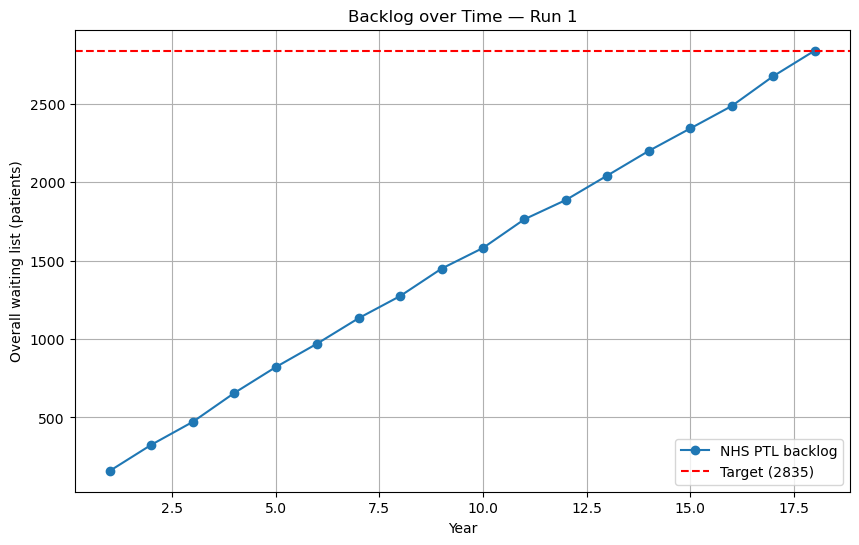

,year,overall_waiting_list
13,14,2200
14,15,2343
15,16,2486
16,17,2676
17,18,2839


In [10]:
# Backlog (NHS PTL) over time — from Run 1 yearly checkpoints.
# yearly_progress is a list of dicts; convert to DataFrame before column access.
backlog_over_time = yearly_progress_df[["year", "overall_waiting_list"]].copy()

plt.figure(figsize=(10, 6))
plt.plot(
    backlog_over_time["year"],
    backlog_over_time["overall_waiting_list"],
    marker="o",
    label="NHS PTL backlog",
)
plt.axhline(y=2835, color="r", linestyle="--", label="Target (2835)")
plt.xlabel("Year")
plt.ylabel("Overall waiting list (patients)")
plt.title("Backlog over Time — Run 1")
plt.grid(True)
plt.legend()
plt.show()

backlog_over_time.tail()


## 7. Run 2: stochastic baseline

**Goal:** quantify random variability of the As-Is scenario at Run 1's `T*`. The same experiment is
replayed over several random seeds and summarised with **95% confidence intervals** for each KPI —
utilisation, the 18-/52-week wait-target percentages, and the full-PTL mean/median/p90 waiting
days. This tells us how much of any later policy effect is real versus noise.

In [11]:
# Fresh template experiment using only parameters defined in this notebook.
matching_period = run1_result["optimal_matching_period_days"]

run2_audit = Audit()
run2_experiment = Experiment(
    audit=run2_audit,
    random_number_set=DEFAULT_RND_SET,
    n_streams=N_STREAMS,
    use_fixed_seed=True,
    scenario_name="notebook_parameters_run2",
    **NOTEBOOK_EXPERIMENT_PARAMETERS,
)

run2_matching_period = float(matching_period)
assert run2_matching_period >= 365, (
    f"matching_period_days={run2_matching_period} looks like years, not days."
)
print(
    f"Using Run 1 T* = {run2_matching_period:.0f} days "
    f"({run2_matching_period / 365:.1f} years); matched={run1_result['matched']}"
)
if not run1_result["matched"]:
    print(
        "WARNING: Run 1 did not meet the target tolerance; "
        f"Run 2 will use the best capped horizon of {run2_matching_period:.0f} days "
        f"({run2_matching_period / 365:.0f} years)."
    )

run2_kpis = [
    "overall_waiting_list_size",
    "first_assessment_waiting_list_size",
    "first_workshop_waiting_list_size",
    "waiting_list_size",
    "rtt_incomplete_mean_days",
    "rtt_completed_mean_days",
    "assessments_per_month",
    "diagnoses_per_month",
    "overall_clinician_utilisation",
    "assessment_utilisation",
    "ptl_under_18_weeks_pct",
    "ptl_over_18_weeks_pct",
    "ptl_under_52_weeks_pct",
    "ptl_over_52_weeks_pct",
    "ptl_mean_wait_days",
    "ptl_median_wait_days",
    "ptl_p90_wait_days",
]

run2_result = run2(
    run2_experiment,
    matching_period_days=run2_matching_period,
    n_reps=N_REP,
    snapshot_window=365,
    confidence_level=0.95,
    seeds=list(range(N_REP)),
    baseline_kpis=run2_kpis,
)

print(
    f"Matching period: {run2_result['matching_period_days']:.0f} days "
    f"({run2_result['matching_period_days'] / 365:.1f} years)"
)
print(f"Replications: {run2_result['n_reps']}")
print(f"Confidence level: {run2_result['confidence_level']:.0%}")

run2_summary_df = pd.DataFrame(run2_result["summary"])
run2_summary_df.style.format({
    "mean": "{:.3f}",
    "std": "{:.3f}",
    "ci_low": "{:.3f}",
    "ci_high": "{:.3f}",
    "confidence_level": "{:.0%}",
})

Using Run 1 T* = 6570 days (18.0 years); matched=True
Matching period: 6570 days (18.0 years)
Replications: 5
Confidence level: 95%


,kpi,n,mean,std,ci_low,ci_high,confidence_level
0,overall_waiting_list_size,5,2805.400,62.280,2728.082,2882.718,95%
1,first_assessment_waiting_list_size,5,2788.000,58.826,2714.970,2861.030,95%
2,first_workshop_waiting_list_size,5,2.800,3.114,-1.067,6.667,95%
3,waiting_list_size,5,316.600,8.706,305.791,327.409,95%
4,rtt_incomplete_mean_days,5,182.062,6.976,173.402,190.722,95%
5,rtt_completed_mean_days,5,3170.541,41.331,3119.230,3221.852,95%
6,assessments_per_month,5,13.242,0.325,12.839,13.646,95%
7,diagnoses_per_month,5,9.890,0.459,9.320,10.460,95%
8,overall_clinician_utilisation,5,0.761,0.005,0.754,0.767,95%
9,assessment_utilisation,5,0.645,0.006,0.637,0.652,95%


## 8. Run 3: increased-capacity policy

**Goal:** measure how much a capacity boost clears the backlog. The model runs As-Is to `T*`, then
**increases weekday clinician capacity from 7 to 28 hours** and continues for a **5-year decay
horizon**. Results compare the policy arm against a no-change control on backlog decay, utilisation,
the 18-/52-week wait-target percentages, and the full-PTL mean/median/p90 waiting days.

In [12]:
# Run 3 uses the same notebook parameters and T* found by Run 1.
run3_audit = Audit()
run3_experiment = Experiment(
    audit=run3_audit,
    random_number_set=DEFAULT_RND_SET,
    n_streams=N_STREAMS,
    use_fixed_seed=True,
    scenario_name="notebook_parameters_run3",
    **NOTEBOOK_EXPERIMENT_PARAMETERS,
)

run3_matching_period = float(run1_result["optimal_matching_period_days"])
run3_decay_period = 5 * 365
baseline_capacity = float(WORKFORCE_HOURS_PER_DAY)
doubled_capacity = 4 * baseline_capacity

run3_result = run3(
    run3_experiment,
    matching_period_days=run3_matching_period,
    decay_period_days=run3_decay_period,
    switch_overrides={"workforce_hours_per_day": doubled_capacity},
    seed=0,
    include_control=True,
    policy_id="double_capacity",
)

policy = run3_result["policy_arm"]
control = run3_result["control_arm"]
comparison = run3_result["comparison"]

print(
    f"Policy switch: day {run3_matching_period:.0f} "
    f"({run3_matching_period / 365:.1f} years)"
)
print(
    f"Decay period: {run3_decay_period:.0f} days "
    f"({run3_decay_period / 365:.1f} years)"
)
print(f"Capacity policy: {baseline_capacity:.0f} -> {doubled_capacity:.0f} hours/weekday")

run3_summary_df = pd.DataFrame([
    {
        "arm": "baseline_control",
        "capacity_hours_per_weekday": baseline_capacity,
        "waiting_list_at_switch": control["waiting_list_at_switch"],
        "overall_waiting_list_at_end": control["kpi_overall_waiting_list_size"],
        "first_assessment_waiting_list_at_end": control["kpi_first_assessment_waiting_list_size"],
        "first_workshop_waiting_list_at_end": control["kpi_first_workshop_waiting_list_size"],
        "backlog_decay_total": control["backlog_decay_total"],
        "backlog_decay_per_month": control["backlog_decay_per_month"],
        "capacity_utilisation": control["kpi_overall_clinician_utilisation"],
        "assessment_utilisation": control["kpi_assessment_utilisation"],
        "ptl_under_18_weeks_pct": control["kpi_ptl_under_18_weeks_pct"],
        "ptl_over_18_weeks_pct": control["kpi_ptl_over_18_weeks_pct"],
        "ptl_under_52_weeks_pct": control["kpi_ptl_under_52_weeks_pct"],
        "ptl_over_52_weeks_pct": control["kpi_ptl_over_52_weeks_pct"],
        "ptl_mean_wait_days": control["kpi_ptl_mean_wait_days"],
        "ptl_median_wait_days": control["kpi_ptl_median_wait_days"],
        "ptl_p90_wait_days": control["kpi_ptl_p90_wait_days"],
        "assessments_per_month": control["kpi_assessments_per_month"],
        "diagnoses_per_month": control["kpi_diagnoses_per_month"],
    },
    {
        "arm": "double_capacity",
        "capacity_hours_per_weekday": doubled_capacity,
        "waiting_list_at_switch": policy["waiting_list_at_switch"],
        "overall_waiting_list_at_end": policy["kpi_overall_waiting_list_size"],
        "first_assessment_waiting_list_at_end": policy["kpi_first_assessment_waiting_list_size"],
        "first_workshop_waiting_list_at_end": policy["kpi_first_workshop_waiting_list_size"],
        "backlog_decay_total": policy["backlog_decay_total"],
        "backlog_decay_per_month": policy["backlog_decay_per_month"],
        "capacity_utilisation": policy["kpi_overall_clinician_utilisation"],
        "assessment_utilisation": policy["kpi_assessment_utilisation"],
        "ptl_under_18_weeks_pct": policy["kpi_ptl_under_18_weeks_pct"],
        "ptl_over_18_weeks_pct": policy["kpi_ptl_over_18_weeks_pct"],
        "ptl_under_52_weeks_pct": policy["kpi_ptl_under_52_weeks_pct"],
        "ptl_over_52_weeks_pct": policy["kpi_ptl_over_52_weeks_pct"],
        "ptl_mean_wait_days": policy["kpi_ptl_mean_wait_days"],
        "ptl_median_wait_days": policy["kpi_ptl_median_wait_days"],
        "ptl_p90_wait_days": policy["kpi_ptl_p90_wait_days"],
        "assessments_per_month": policy["kpi_assessments_per_month"],
        "diagnoses_per_month": policy["kpi_diagnoses_per_month"],
    },
])

print(
f"Policy effect at year {run3_decay_period/365:.0f}: {comparison['delta_wl_end']:+.0f} patients "
    "versus the no-change control"
)
run3_summary_df.style.format({
    "capacity_hours_per_weekday": "{:.0f}",
    "waiting_list_at_switch": "{:.0f}",
    "overall_waiting_list_at_end": "{:.0f}",
    "first_assessment_waiting_list_at_end": "{:.0f}",
    "first_workshop_waiting_list_at_end": "{:.0f}",
    "backlog_decay_total": "{:.0f}",
    "backlog_decay_per_month": "{:.2f}",
    "capacity_utilisation": "{:.1%}",
    "assessment_utilisation": "{:.1%}",
    "ptl_under_18_weeks_pct": "{:.1f}%",
    "ptl_over_18_weeks_pct": "{:.1f}%",
    "ptl_under_52_weeks_pct": "{:.1f}%",
    "ptl_over_52_weeks_pct": "{:.1f}%",
    "ptl_mean_wait_days": "{:.1f}",
    "ptl_median_wait_days": "{:.1f}",
    "ptl_p90_wait_days": "{:.1f}",
    "assessments_per_month": "{:.2f}",
    "diagnoses_per_month": "{:.2f}",
})

Policy switch: day 6570 (18.0 years)
Decay period: 1825 days (5.0 years)
Capacity policy: 7 -> 28 hours/weekday
Policy effect at year 5: -3236 patients versus the no-change control


,arm,capacity_hours_per_weekday,waiting_list_at_switch,overall_waiting_list_at_end,first_assessment_waiting_list_at_end,first_workshop_waiting_list_at_end,backlog_decay_total,backlog_decay_per_month,capacity_utilisation,assessment_utilisation,ptl_under_18_weeks_pct,ptl_over_18_weeks_pct,ptl_under_52_weeks_pct,ptl_over_52_weeks_pct,ptl_mean_wait_days,ptl_median_wait_days,ptl_p90_wait_days,assessments_per_month,diagnoses_per_month
0,baseline_control,7,2839,3645,3626,4,-806,-13.44,76.5%,64.3%,3.0%,97.0%,8.7%,91.3%,2077.9,2077.0,3771.3,13.13,10.39
1,double_capacity,28,2839,409,320,2,2430,40.53,96.0%,83.1%,26.7%,73.3%,77.8%,22.2%,241.6,245.1,427.5,67.73,51.17


## 9. Run 3 grid: capacity vs decay

**Goal:** find *how much* capacity, for *how long*, is needed to hit the waiting-time standards.
Sweep weekday capacity across **7 → 29 hours** (steps of 2) and decay horizons of **2, 3, 4, 5**
years. Every scenario starts from Run 1's `T*` with the same notebook parameters and seed, so they
are directly comparable. Capacity **7** is the no-change baseline within each decay length.

In [13]:
# Capacity × decay grid at Run 1's T*.
run3_grid_matching_period = float(run1_result["optimal_matching_period_days"])
run3_grid_capacities = list(range(7, 35, 7))
run3_grid_decay_years = [2, 3, 4, 5]

run3_grid_rows = []
for capacity in run3_grid_capacities:
    for decay_years in run3_grid_decay_years:
        decay_days = decay_years * 365
        grid_experiment = Experiment(
            audit=Audit(),
            random_number_set=DEFAULT_RND_SET,
            n_streams=N_STREAMS,
            use_fixed_seed=True,
            scenario_name=f"run3_cap{capacity}_decay{decay_years}y",
            **NOTEBOOK_EXPERIMENT_PARAMETERS,
        )
        result = run3(
            grid_experiment,
            matching_period_days=run3_grid_matching_period,
            decay_period_days=decay_days,
            switch_overrides={"workforce_hours_per_day": float(capacity)},
            seed=0,
            include_control=False,
            policy_id=f"capacity_{capacity}",
        )
        arm = result["policy_arm"]
        run3_grid_rows.append({
            "capacity_hours": capacity,
            "decay_years": decay_years,
            "decay_days": decay_days,
            "waiting_list_at_switch": arm["waiting_list_at_switch"],
            "waiting_list_at_end": arm["waiting_list_at_end"],
            "first_assessment_waiting_list_at_end": arm["kpi_first_assessment_waiting_list_size"],
            "first_workshop_waiting_list_at_end": arm["kpi_first_workshop_waiting_list_size"],
            "backlog_change": arm["backlog_decay_total"],
            "backlog_change_per_month": arm["backlog_decay_per_month"],
            "capacity_utilisation": arm["kpi_overall_clinician_utilisation"],
            "assessment_utilisation": arm["kpi_assessment_utilisation"],
            "ptl_under_18_weeks_pct": arm["kpi_ptl_under_18_weeks_pct"],
            "ptl_over_18_weeks_pct": arm["kpi_ptl_over_18_weeks_pct"],
            "ptl_under_52_weeks_pct": arm["kpi_ptl_under_52_weeks_pct"],
            "ptl_over_52_weeks_pct": arm["kpi_ptl_over_52_weeks_pct"],
            "ptl_mean_wait_days": arm["kpi_ptl_mean_wait_days"],
            "ptl_median_wait_days": arm["kpi_ptl_median_wait_days"],
            "ptl_p90_wait_days": arm["kpi_ptl_p90_wait_days"],
            "assessments_per_month": arm["kpi_assessments_per_month"],
            "diagnoses_per_month": arm["kpi_diagnoses_per_month"],
        })
        print(
            f"capacity={capacity:>2} | decay={decay_years}y | "
            f"WL {arm['waiting_list_at_switch']:.0f} -> {arm['waiting_list_at_end']:.0f} | "
            f"Δ {arm['backlog_decay_total']:+.0f} | "
            f"≤18w {arm['kpi_ptl_under_18_weeks_pct']:.1f}% | "
            f">18w {arm['kpi_ptl_over_18_weeks_pct']:.1f}% | "
            f"≤52w {arm['kpi_ptl_under_52_weeks_pct']:.1f}% | "
            f">52w {arm['kpi_ptl_over_52_weeks_pct']:.1f}%"
        )

run3_grid_df = pd.DataFrame(run3_grid_rows)

print(
    f"\nGrid complete: T*={run3_grid_matching_period:.0f} days "
    f"({run3_grid_matching_period / 365:.1f} years), "
    f"{len(run3_grid_df)} scenarios"
)

# Waiting-list end state by capacity and decay length.
run3_grid_wl = run3_grid_df.pivot(
    index="capacity_hours", columns="decay_years", values="waiting_list_at_end"
)
print("\nWaiting list at end of decay")
display(run3_grid_wl.style.format("{:.0f}"))

# 18-week under-target percentage by capacity and decay length.
run3_grid_18 = run3_grid_df.pivot(
    index="capacity_hours", columns="decay_years", values="ptl_under_18_weeks_pct"
)
print("\n% full PTL ≤ 18 weeks")
display(run3_grid_18.style.format("{:.1f}%"))

for wait_stat, title in (
    ("ptl_mean_wait_days", "Mean PTL wait (days)"),
    ("ptl_median_wait_days", "Median PTL wait (days)"),
    ("ptl_p90_wait_days", "P90 PTL wait (days)"),
):
    wait_table = run3_grid_df.pivot(
        index="capacity_hours", columns="decay_years", values=wait_stat
    )
    print(f"\n{title}")
    display(wait_table.style.format("{:.1f}"))

# Full scenario table.
run3_grid_df.style.format({
    "waiting_list_at_switch": "{:.0f}",
    "waiting_list_at_end": "{:.0f}",
    "backlog_change": "{:.0f}",
    "backlog_change_per_month": "{:.2f}",
    "capacity_utilisation": "{:.1%}",
    "assessment_utilisation": "{:.1%}",
    "ptl_under_18_weeks_pct": "{:.1f}%",
    "ptl_over_18_weeks_pct": "{:.1f}%",
    "ptl_under_52_weeks_pct": "{:.1f}%",
    "ptl_over_52_weeks_pct": "{:.1f}%",
    "ptl_mean_wait_days": "{:.1f}",
    "ptl_median_wait_days": "{:.1f}",
    "ptl_p90_wait_days": "{:.1f}",
    "assessments_per_month": "{:.2f}",
    "diagnoses_per_month": "{:.2f}",
})

capacity= 7 | decay=2y | WL 2839 -> 3141 | Δ -302 | ≤18w 3.6% | >18w 96.4% | ≤52w 10.5% | >52w 89.5%
capacity= 7 | decay=3y | WL 2839 -> 3295 | Δ -456 | ≤18w 3.1% | >18w 96.9% | ≤52w 9.2% | >52w 90.8%
capacity= 7 | decay=4y | WL 2839 -> 3486 | Δ -647 | ≤18w 3.9% | >18w 96.1% | ≤52w 9.9% | >52w 90.1%
capacity= 7 | decay=5y | WL 2839 -> 3645 | Δ -806 | ≤18w 3.0% | >18w 97.0% | ≤52w 8.7% | >52w 91.3%
capacity=14 | decay=2y | WL 2839 -> 2711 | Δ +128 | ≤18w 4.2% | >18w 95.8% | ≤52w 12.1% | >52w 87.9%
capacity=14 | decay=3y | WL 2839 -> 2647 | Δ +192 | ≤18w 3.8% | >18w 96.2% | ≤52w 11.4% | >52w 88.6%
capacity=14 | decay=4y | WL 2839 -> 2613 | Δ +226 | ≤18w 5.2% | >18w 94.8% | ≤52w 13.2% | >52w 86.8%
capacity=14 | decay=5y | WL 2839 -> 2540 | Δ +299 | ≤18w 4.3% | >18w 95.7% | ≤52w 12.5% | >52w 87.5%
capacity=21 | decay=2y | WL 2839 -> 2302 | Δ +537 | ≤18w 4.9% | >18w 95.1% | ≤52w 14.3% | >52w 85.7%
capacity=21 | decay=3y | WL 2839 -> 2015 | Δ +824 | ≤18w 5.0% | >18w 95.0% | ≤52w 15.0% | >52w

decay_years,2,3,4,5
capacity_hours,,,,
7,3141,3295,3486,3645
14,2711,2647,2613,2540
21,2302,2015,1745,1461
28,1908,1396,922,409



% full PTL ≤ 18 weeks


decay_years,2,3,4,5
capacity_hours,,,,
7,3.6%,3.1%,3.9%,3.0%
14,4.2%,3.8%,5.2%,4.3%
21,4.9%,5.0%,7.7%,7.5%
28,5.9%,7.2%,14.6%,26.7%



Mean PTL wait (days)


...


Median PTL wait (days)


decay_years,2,3,4,5
capacity_hours,,,,
7,1791.0,1886.9,1985.0,2077.0
14,1536.2,1526.0,1489.2,1429.8
21,1303.9,1181.4,969.7,818.5
28,1108.6,801.3,522.1,245.1



P90 PTL wait (days)


decay_years,2,3,4,5
capacity_hours,,,,
7,3295.2,3443.8,3601.4,3771.3
14,2824.4,2756.1,2684.3,2588.0
21,2379.0,2090.8,1796.6,1476.5
28,1977.5,1473.6,917.9,427.5


,capacity_hours,decay_years,decay_days,waiting_list_at_switch,waiting_list_at_end,first_assessment_waiting_list_at_end,first_workshop_waiting_list_at_end,backlog_change,backlog_change_per_month,capacity_utilisation,assessment_utilisation,ptl_under_18_weeks_pct,ptl_over_18_weeks_pct,ptl_under_52_weeks_pct,ptl_over_52_weeks_pct,ptl_mean_wait_days,ptl_median_wait_days,ptl_p90_wait_days,assessments_per_month,diagnoses_per_month
0,7,2,730,2839,3141,3120,6,-302,-12.59,76.6%,64.3%,3.6%,96.4%,10.5%,89.5%,1809.6,1791.0,3295.2,13.43,10.67
1,7,3,1095,2839,3295,3274,3,-456,-12.68,76.4%,64.2%,3.1%,96.9%,9.2%,90.8%,1914.4,1886.9,3443.8,13.18,10.51
2,7,4,1460,2839,3486,3464,4,-647,-13.49,76.4%,64.2%,3.9%,96.1%,9.9%,90.1%,1987.5,1985.0,3601.4,13.20,10.40
3,7,5,1825,2839,3645,3626,4,-806,-13.44,76.5%,64.3%,3.0%,97.0%,8.7%,91.3%,2077.9,2077.0,3771.3,13.13,10.39
4,14,2,730,2839,2711,2668,1,128,5.34,91.1%,78.4%,4.2%,95.8%,12.1%,87.9%,1557.1,1536.2,2824.4,31.94,25.31
5,14,3,1095,2839,2647,2604,2,192,5.34,91.1%,78.6%,3.8%,96.2%,11.4%,88.6%,1536.3,1526.0,2756.1,31.49,24.54
6,14,4,1460,2839,2613,2568,0,226,4.71,91.1%,78.7%,5.2%,94.8%,13.2%,86.8%,1480.2,1489.2,2684.3,31.69,24.62
7,14,5,1825,2839,2540,2491,5,299,4.99,91.1%,78.6%,4.3%,95.7%,12.5%,87.5%,1438.8,1429.8,2588.0,31.84,24.38
8,21,2,730,2839,2302,2240,1,537,22.39,95.1%,82.4%,4.9%,95.1%,14.3%,85.7%,1319.3,1303.9,2379.0,49.33,38.19
9,21,3,1095,2839,2015,1937,7,824,22.90,95.1%,82.2%,5.0%,95.0%,15.0%,85.0%,1168.8,1181.4,2090.8,49.65,38.05


## 10. Run 3 grid: heatmaps

Heatmaps of end-of-decay outcomes across capacity (rows) and decay length (columns). Use these to
read off, at a glance, how much capacity and how many years are needed before PTL size and the
waiting-time standards visibly improve.

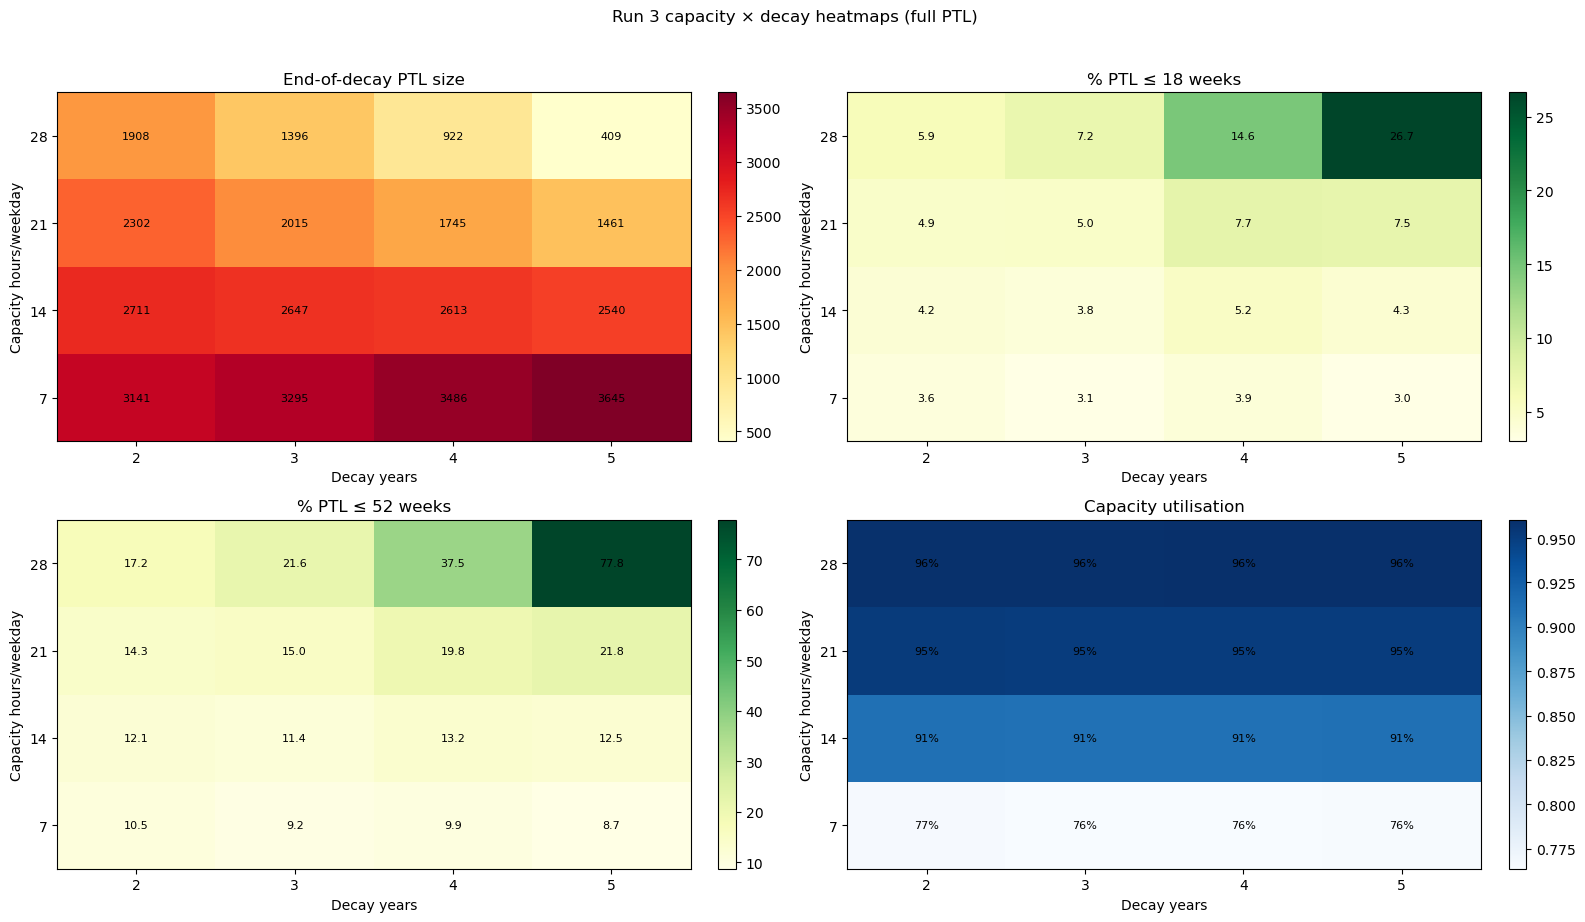

In [14]:
# Heatmaps from the capacity × decay grid.
heatmap_metrics = [
    ("waiting_list_at_end", "End-of-decay PTL size", "{:.0f}", "YlOrRd"),
    ("ptl_under_18_weeks_pct", "% PTL ≤ 18 weeks", "{:.1f}", "YlGn"),
    ("ptl_under_52_weeks_pct", "% PTL ≤ 52 weeks", "{:.1f}", "YlGn"),
    ("capacity_utilisation", "Capacity utilisation", "{:.0%}", "Blues"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()
for ax, (metric, title, fmt, cmap) in zip(axes, heatmap_metrics):
    table = run3_grid_df.pivot(
        index="capacity_hours", columns="decay_years", values=metric
    )
    im = ax.imshow(table.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_xlabel("Decay years")
    ax.set_ylabel("Capacity hours/weekday")
    ax.set_title(title)
    for i, cap in enumerate(table.index):
        for j, years in enumerate(table.columns):
            value = table.loc[cap, years]
            ax.text(j, i, fmt.format(value), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Run 3 capacity × decay heatmaps (full PTL)", y=1.02)
plt.tight_layout()
plt.show()

## 11. Run 3: administrative-removal policy

**Goal:** test a non-capacity lever. At `T*`, raise the administrative-removal rate
(`pct_admin_removal`) from **10% to 20%** while holding capacity at **7 hours/weekday**, then
compare against the no-change control over a **5-year** decay horizon using the full-PTL measures.

In [15]:
# Administrative-removal policy: 10% -> 20%; no other parameter changes.
admin_policy_matching_period = float(run1_result["optimal_matching_period_days"])
admin_policy_decay_period = 5 * 365
admin_removal_baseline = float(PCT_ADMIN_REMOVAL)
admin_removal_policy = 0.20

admin_policy_result = run3(
    Experiment(
        audit=Audit(),
        random_number_set=DEFAULT_RND_SET,
        n_streams=N_STREAMS,
        use_fixed_seed=True,
        scenario_name="run3_admin_removal_20pct",
        **NOTEBOOK_EXPERIMENT_PARAMETERS,
    ),
    matching_period_days=admin_policy_matching_period,
    decay_period_days=admin_policy_decay_period,
    switch_overrides={"pct_admin_removal": admin_removal_policy},
    seed=0,
    include_control=True,
    policy_id="admin_removal_20pct",
)

admin_policy = admin_policy_result["policy_arm"]
admin_control = admin_policy_result["control_arm"]
admin_comparison = admin_policy_result["comparison"]

print(
    f"Administrative removal: {admin_removal_baseline:.0%} -> {admin_removal_policy:.0%}; "
    f"capacity remains {WORKFORCE_HOURS_PER_DAY} hours/weekday"
)
print(
    f"Policy effect at year 5: {admin_comparison['delta_wl_end']:+.0f} patients "
    "versus the no-change control"
)

admin_policy_summary_df = pd.DataFrame([
    {
        "arm": name,
        "admin_removal_probability": prob,
        "overall_waiting_list_at_end": arm["kpi_overall_waiting_list_size"],
        "first_assessment_waiting_list_at_end": arm["kpi_first_assessment_waiting_list_size"],
        "first_workshop_waiting_list_at_end": arm["kpi_first_workshop_waiting_list_size"],
        "backlog_change": arm["backlog_decay_total"],
        "ptl_under_18_weeks_pct": arm["kpi_ptl_under_18_weeks_pct"],
        "ptl_under_52_weeks_pct": arm["kpi_ptl_under_52_weeks_pct"],
        "ptl_mean_wait_days": arm["kpi_ptl_mean_wait_days"],
        "ptl_median_wait_days": arm["kpi_ptl_median_wait_days"],
        "ptl_p90_wait_days": arm["kpi_ptl_p90_wait_days"],
        "capacity_utilisation": arm["kpi_overall_clinician_utilisation"],
        "assessments_per_month": arm["kpi_assessments_per_month"],
    }
    for name, prob, arm in (
        ("baseline_control", admin_removal_baseline, admin_control),
        ("admin_removal_20pct", admin_removal_policy, admin_policy),
    )
])
admin_policy_summary_df.style.format({
    "admin_removal_probability": "{:.0%}",
    "overall_waiting_list_at_end": "{:.0f}",
    "first_assessment_waiting_list_at_end": "{:.0f}",
    "first_workshop_waiting_list_at_end": "{:.0f}",
    "backlog_change": "{:.0f}",
    "ptl_under_18_weeks_pct": "{:.1f}%",
    "ptl_under_52_weeks_pct": "{:.1f}%",
    "ptl_mean_wait_days": "{:.1f}",
    "ptl_median_wait_days": "{:.1f}",
    "ptl_p90_wait_days": "{:.1f}",
    "capacity_utilisation": "{:.1%}",
    "assessments_per_month": "{:.2f}",
})

Administrative removal: 10% -> 20%; capacity remains 7 hours/weekday
Policy effect at year 5: -183 patients versus the no-change control


,arm,admin_removal_probability,overall_waiting_list_at_end,first_assessment_waiting_list_at_end,first_workshop_waiting_list_at_end,backlog_change,ptl_under_18_weeks_pct,ptl_under_52_weeks_pct,ptl_mean_wait_days,ptl_median_wait_days,ptl_p90_wait_days,capacity_utilisation,assessments_per_month
0,baseline_control,10%,3645,3626,4,-806,3.0%,8.7%,2077.9,2077.0,3771.3,76.5%,13.13
1,admin_removal_20pct,20%,3462,3446,4,-623,2.9%,8.2%,2139.1,2197.6,3788.7,76.3%,13.13


## 12. Run 3: plots from the grid

All charts below use **only** `run3_grid_df` from the `run3` capacity × decay search.
No extra `single_run` trajectories are built.

Interpretation:
- **decay years** is the post-switch horizon
- **capacity hours** is the policy change at T*
- capacity **7** is the no-change control within each decay length

In [16]:
# Prepare grid-based plot frames from run3 results only.
assert "run3_grid_df" in dir(), "Run the capacity × decay grid cell first"

grid = run3_grid_df.copy().sort_values(["capacity_hours", "decay_years"])
grid_capacities = sorted(grid["capacity_hours"].unique())
grid_decay_years = sorted(grid["decay_years"].unique())

# At-switch backlog is the same for all arms (shared T* / seed).
grid_switch_backlog = float(grid["waiting_list_at_switch"].iloc[0])

# Include decay_years=0 (= switch time) so backlog "over time" starts at T*.
grid_backlog_rows = []
for capacity in grid_capacities:
    grid_backlog_rows.append({
        "capacity_hours": capacity,
        "decay_years": 0,
        "waiting_list_at_end": grid_switch_backlog,
        "ptl_under_18_weeks_pct": np.nan,
        "ptl_under_52_weeks_pct": np.nan,
        "ptl_mean_wait_days": np.nan,
        "ptl_median_wait_days": np.nan,
        "ptl_p90_wait_days": np.nan,
        "capacity_utilisation": np.nan,
        "assessment_utilisation": np.nan,
        "assessments_per_month": np.nan,
        "diagnoses_per_month": np.nan,
    })
grid_plot_df = pd.concat([pd.DataFrame(grid_backlog_rows), grid], ignore_index=True)
grid_plot_df = grid_plot_df.sort_values(["capacity_hours", "decay_years"])

# Control = capacity 7 within each decay year.
control = (
    grid.loc[grid["capacity_hours"] == 7, [
        "decay_years",
        "waiting_list_at_end",
        "ptl_under_18_weeks_pct",
        "ptl_under_52_weeks_pct",
        "ptl_median_wait_days",
        "ptl_p90_wait_days",
    ]]
    .rename(columns=lambda c: f"control_{c}" if c != "decay_years" else c)
)
grid_delta_df = grid.merge(control, on="decay_years", how="left")
grid_delta_df = grid_delta_df[grid_delta_df["capacity_hours"] != 7].copy()
grid_delta_df["delta_ptl"] = (
    grid_delta_df["waiting_list_at_end"] - grid_delta_df["control_waiting_list_at_end"]
)
grid_delta_df["delta_under_18"] = (
    grid_delta_df["ptl_under_18_weeks_pct"] - grid_delta_df["control_ptl_under_18_weeks_pct"]
)
grid_delta_df["delta_under_52"] = (
    grid_delta_df["ptl_under_52_weeks_pct"] - grid_delta_df["control_ptl_under_52_weeks_pct"]
)
grid_delta_df["delta_median"] = (
    grid_delta_df["ptl_median_wait_days"] - grid_delta_df["control_ptl_median_wait_days"]
)
grid_delta_df["delta_p90"] = (
    grid_delta_df["ptl_p90_wait_days"] - grid_delta_df["control_ptl_p90_wait_days"]
)

print(
    f"Grid scenarios: {len(grid)} | capacities={grid_capacities} | "
    f"decay years={grid_decay_years} | switch PTL={grid_switch_backlog:.0f}"
)
grid.head()

Grid scenarios: 16 | capacities=[7, 14, 21, 28] | decay years=[2, 3, 4, 5] | switch PTL=2839


,capacity_hours,decay_years,decay_days,waiting_list_at_switch,waiting_list_at_end,first_assessment_waiting_list_at_end,first_workshop_waiting_list_at_end,backlog_change,backlog_change_per_month,capacity_utilisation,assessment_utilisation,ptl_under_18_weeks_pct,ptl_over_18_weeks_pct,ptl_under_52_weeks_pct,ptl_over_52_weeks_pct,ptl_mean_wait_days,ptl_median_wait_days,ptl_p90_wait_days,assessments_per_month,diagnoses_per_month
0,7,2,730,2839.0,3141.0,3120,6,-302.0,-12.591952,0.765677,0.642845,3.597580,96.402420,10.474371,89.525629,1809.645537,1791.000000,3295.227353,13.425856,10.673973
1,7,3,1095,2839.0,3295.0,3274,3,-456.0,-12.675342,0.764328,0.642071,3.065250,96.934750,9.165402,90.834598,1914.410510,1886.892953,3443.783818,13.175685,10.507192
2,7,4,1460,2839.0,3486.0,3464,4,-647.0,-13.488399,0.763769,0.642300,3.872633,96.127367,9.925416,90.074584,1987.548772,1985.005405,3601.446368,13.196533,10.402954
3,7,5,1825,2839.0,3645.0,3626,4,-806.0,-13.442534,0.764721,0.642704,2.990398,97.009602,8.724280,91.275720,2077.884978,2076.972388,3771.313556,13.125651,10.390445
4,14,2,730,2839.0,2711.0,2668,1,128.0,5.336986,0.911233,0.784270,4.168204,95.831796,12.135743,87.864257,1557.149484,1536.195390,2824.369435,31.938527,25.308990


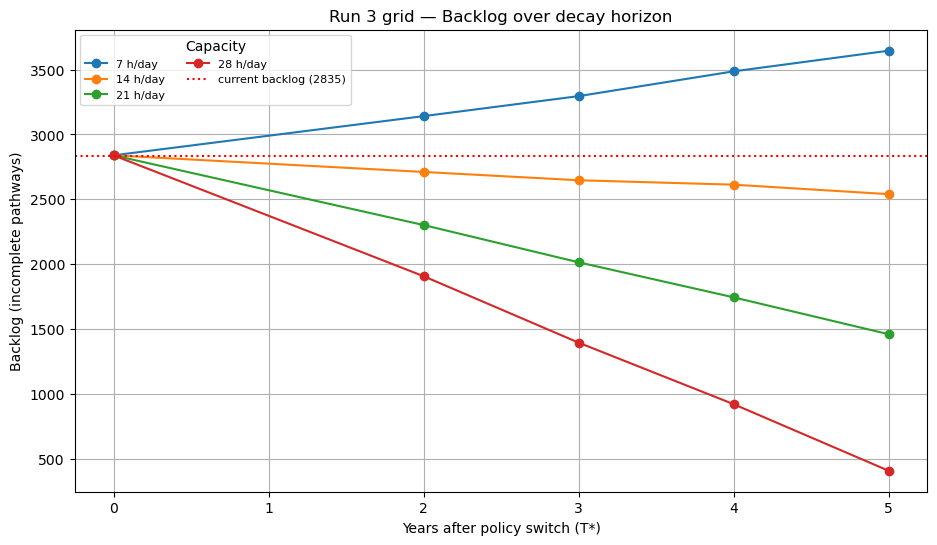

In [17]:
# 1) Backlog over decay horizon — one line per capacity (from run3 grid)
plt.figure(figsize=(11, 6))
for capacity in grid_capacities:
    sub = grid_plot_df[grid_plot_df["capacity_hours"] == capacity]
    plt.plot(
        sub["decay_years"],
        sub["waiting_list_at_end"],
        marker="o",
        label=f"{capacity} h/day",
    )
plt.axhline(2835, color="r", linestyle=":", label="current backlog (2835)")
plt.xlabel("Years after policy switch (T*)")
plt.ylabel("Backlog (incomplete pathways)")
plt.title("Run 3 grid — Backlog over decay horizon")
plt.grid(True)
plt.legend(title="Capacity", ncol=2, fontsize=8)
plt.show()

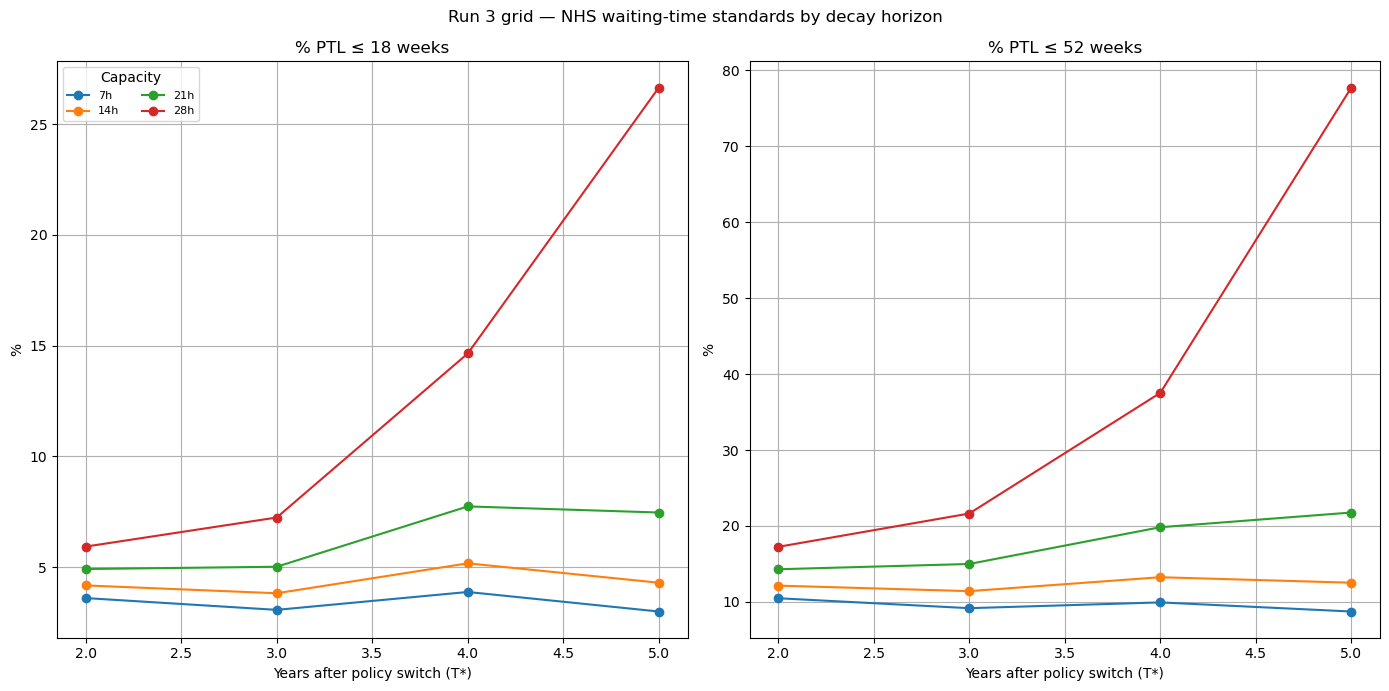

In [18]:
# 2) PTL waiting-time standards vs decay years — from run3 grid
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)
for capacity in grid_capacities:
    sub = grid[grid["capacity_hours"] == capacity]
    axes[0].plot(sub["decay_years"], sub["ptl_under_18_weeks_pct"], marker="o", label=f"{capacity}h")
    axes[1].plot(sub["decay_years"], sub["ptl_under_52_weeks_pct"], marker="o", label=f"{capacity}h")
axes[0].set_title("% PTL ≤ 18 weeks")
axes[1].set_title("% PTL ≤ 52 weeks")
for ax in axes:
    ax.set_xlabel("Years after policy switch (T*)")
    ax.set_ylabel("%")
    ax.grid(True)
axes[0].legend(title="Capacity", ncol=2, fontsize=8)
plt.suptitle("Run 3 grid — NHS waiting-time standards by decay horizon")
plt.tight_layout()
plt.show()

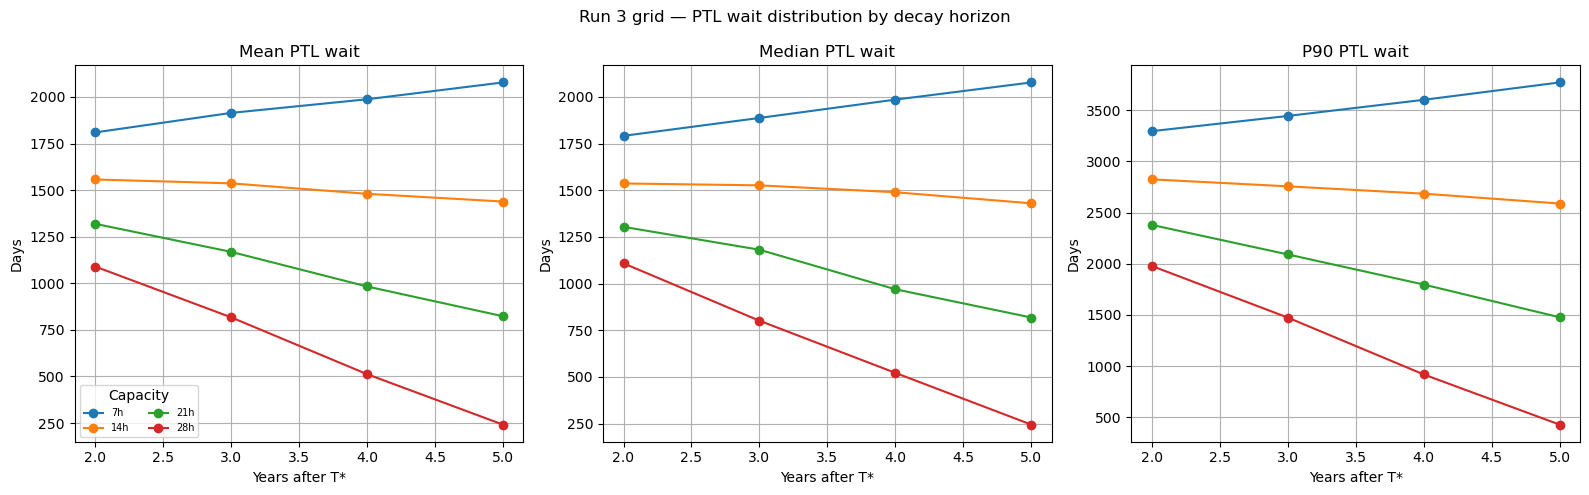

In [19]:
# 3) Mean / median / p90 PTL wait vs decay years — from run3 grid
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, col, title in (
    (axes[0], "ptl_mean_wait_days", "Mean PTL wait"),
    (axes[1], "ptl_median_wait_days", "Median PTL wait"),
    (axes[2], "ptl_p90_wait_days", "P90 PTL wait"),
):
    for capacity in grid_capacities:
        sub = grid[grid["capacity_hours"] == capacity]
        ax.plot(sub["decay_years"], sub[col], marker="o", label=f"{capacity}h")
    ax.set_xlabel("Years after T*")
    ax.set_ylabel("Days")
    ax.set_title(title)
    ax.grid(True)
axes[0].legend(title="Capacity", ncol=2, fontsize=7)
plt.suptitle("Run 3 grid — PTL wait distribution by decay horizon")
plt.tight_layout()
plt.show()

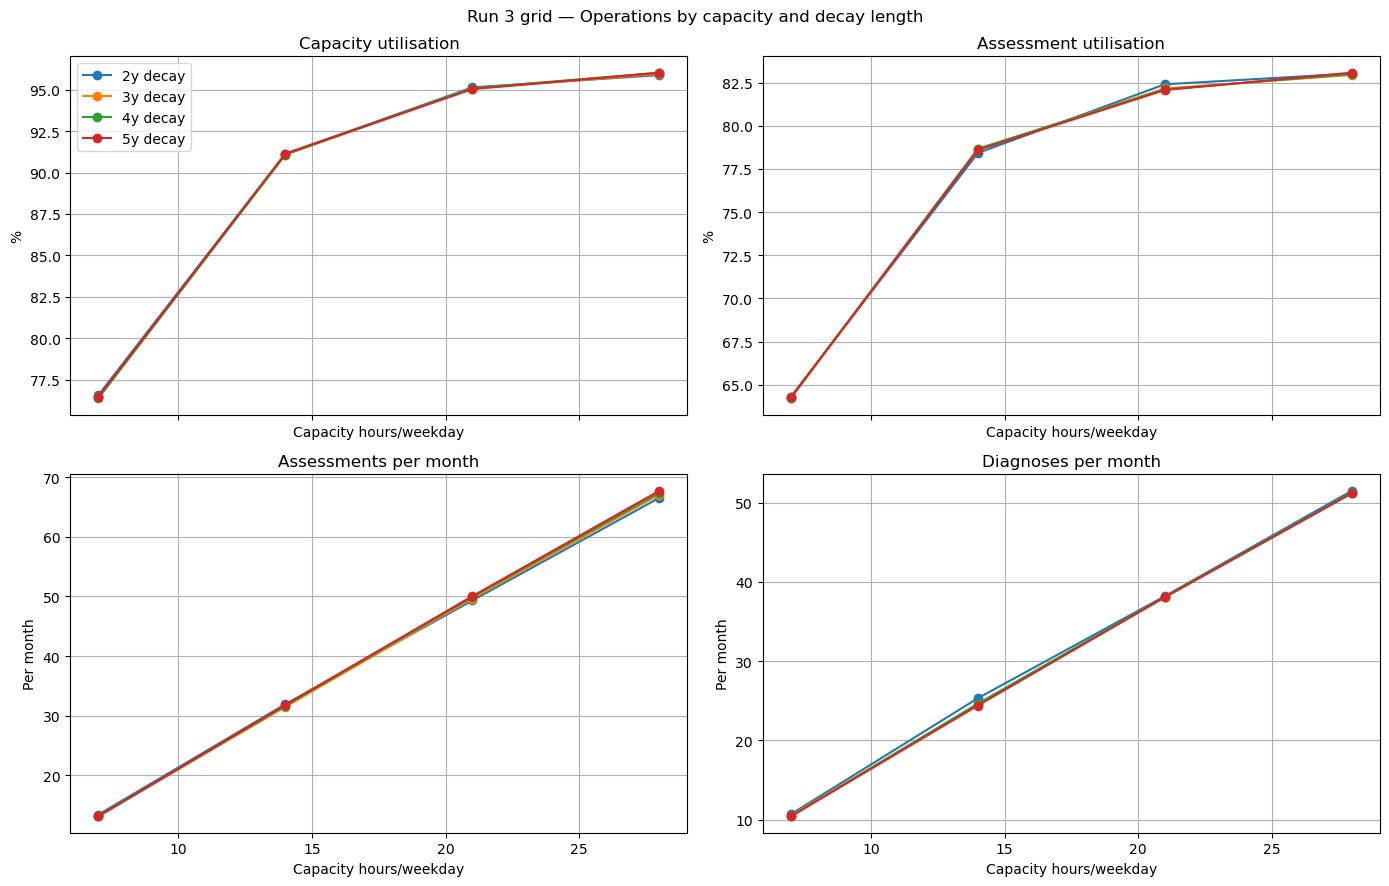

In [20]:
# 4) Utilisation and throughput vs capacity — one panel per decay year
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
ops_panels = [
    (axes[0, 0], "capacity_utilisation", "Capacity utilisation", True),
    (axes[0, 1], "assessment_utilisation", "Assessment utilisation", True),
    (axes[1, 0], "assessments_per_month", "Assessments per month", False),
    (axes[1, 1], "diagnoses_per_month", "Diagnoses per month", False),
]
for ax, col, title, is_pct in ops_panels:
    for years in grid_decay_years:
        sub = grid[grid["decay_years"] == years].sort_values("capacity_hours")
        y = sub[col] * 100 if is_pct else sub[col]
        ax.plot(sub["capacity_hours"], y, marker="o", label=f"{years}y decay")
    ax.set_xlabel("Capacity hours/weekday")
    ax.set_ylabel("%" if is_pct else "Per month")
    ax.set_title(title)
    ax.grid(True)
axes[0, 0].legend()
plt.suptitle("Run 3 grid — Operations by capacity and decay length")
plt.tight_layout()
plt.show()

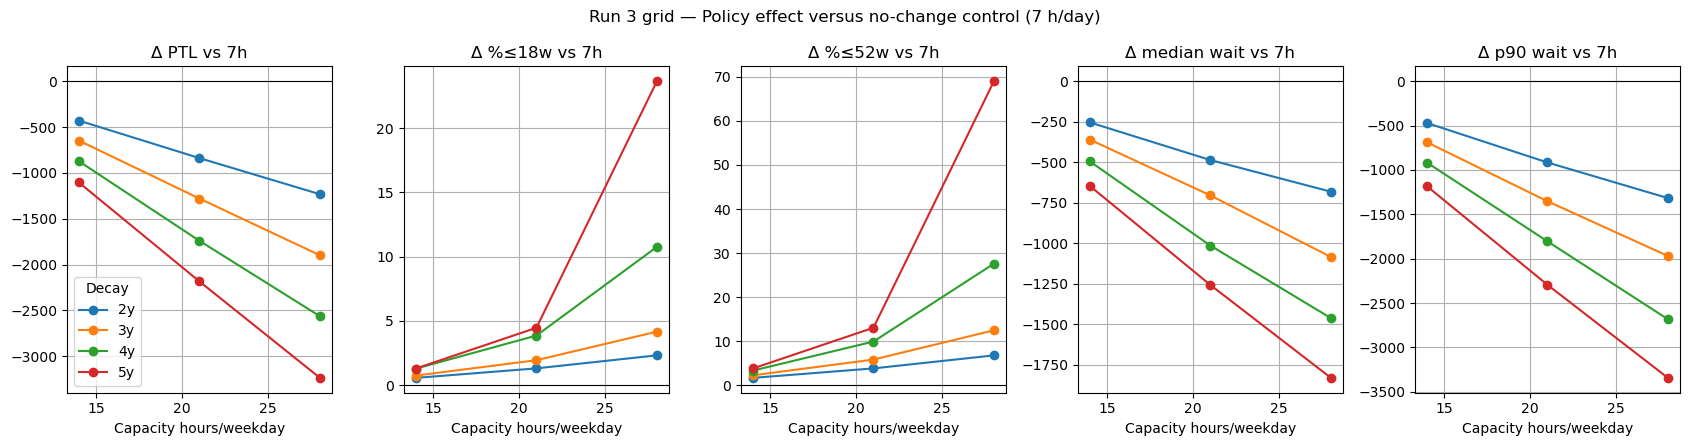

,capacity_hours,decay_years,delta_ptl,delta_under_18,delta_under_52,delta_median,delta_p90
7,14,5,-1105,1.3,3.8,-647.1,-1183.3
11,21,5,-2184,4.5,13.0,-1258.5,-2294.8
15,28,5,-3236,23.7,69.0,-1831.9,-3343.8


In [21]:
# 5) End-of-decay deltas versus capacity=7 control — from run3 grid
fig, axes = plt.subplots(1, 5, figsize=(17, 4.5))
delta_panels = [
    ("delta_ptl", "Δ PTL vs 7h"),
    ("delta_under_18", "Δ %≤18w vs 7h"),
    ("delta_under_52", "Δ %≤52w vs 7h"),
    ("delta_median", "Δ median wait vs 7h"),
    ("delta_p90", "Δ p90 wait vs 7h"),
]
for ax, (col, title) in zip(axes, delta_panels):
    for years in grid_decay_years:
        sub = grid_delta_df[grid_delta_df["decay_years"] == years].sort_values("capacity_hours")
        ax.plot(sub["capacity_hours"], sub[col], marker="o", label=f"{years}y")
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xlabel("Capacity hours/weekday")
    ax.set_title(title)
    ax.grid(True)
axes[0].legend(title="Decay")
plt.suptitle("Run 3 grid — Policy effect versus no-change control (7 h/day)")
plt.tight_layout()
plt.show()

# Compact table for the longest decay horizon.
longest = max(grid_decay_years)
display(
    grid_delta_df.loc[
        grid_delta_df["decay_years"] == longest,
        [
            "capacity_hours",
            "decay_years",
            "delta_ptl",
            "delta_under_18",
            "delta_under_52",
            "delta_median",
            "delta_p90",
        ],
    ].style.format({
        "delta_ptl": "{:.0f}",
        "delta_under_18": "{:.1f}",
        "delta_under_52": "{:.1f}",
        "delta_median": "{:.1f}",
        "delta_p90": "{:.1f}",
    })
)

## 13. Policy tests — double capacity vs double admin removal

Side-by-side **Run 3** tests at Run 1's `T*`, each with a **5-year decay** horizon and the same
notebook parameters:

| Policy | Change at `T*` |
|--------|----------------|
| **Double capacity** | Weekday clinician hours **7 → 14** (`×2`) |
| **Double admin removal** | Administrative removal rate **10% → 20%** (`×2`) |

Each test runs a policy arm and a no-change control arm. **Positive `delta_wl_end`** means the
policy cleared more backlog than the control by the end of the decay window.



capacity 7 -> 14 h/weekday
  PTL at T*: 2839 | control end: 3645 | policy end: 2540 | delta vs control: -1105

admin removal 10% -> 20%
  PTL at T*: 2839 | control end: 3645 | policy end: 3462 | delta vs control: -183


,policy,policy_change,waiting_list_at_switch,control_ptl_at_end,policy_ptl_at_end,delta_wl_end_vs_control,backlog_decay_total,backlog_decay_per_month,ptl_under_18_weeks_pct,ptl_under_52_weeks_pct,ptl_mean_wait_days,capacity_utilisation,assessments_per_month
0,double_capacity_2x,capacity 7 -> 14 h/weekday,2839,3645,2540,-1105,299,4.99,4.3%,12.5%,1438.8,91.1%,31.84
1,double_admin_removal_2x,admin removal 10% -> 20%,2839,3645,3462,-183,-623,-10.39,2.9%,8.2%,2139.1,76.3%,13.13


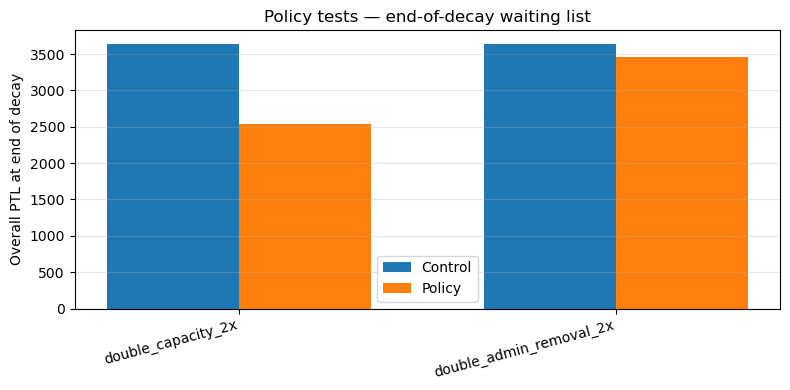

,policy,policy_change,waiting_list_at_switch,control_ptl_at_end,policy_ptl_at_end,delta_wl_end_vs_control,backlog_decay_total,backlog_decay_per_month,ptl_under_18_weeks_pct,ptl_under_52_weeks_pct,ptl_mean_wait_days,capacity_utilisation,assessments_per_month
0,double_capacity_2x,capacity 7 -> 14 h/weekday,2839.0,3645,2540,-1105.0,299.0,4.986747,4.291339,12.519685,1438.771209,0.911416,31.838459
1,double_admin_removal_2x,admin removal 10% -> 20%,2839.0,3645,3462,-183.0,-623.0,-10.390445,2.888504,8.232236,2139.052847,0.762788,13.125651


In [22]:
# Policy tests at T*: double capacity (7 -> 14 h) and double admin removal (10% -> 20%).
policy_test_matching_period = float(run1_result["optimal_matching_period_days"])
policy_test_decay_period = 5 * 365
baseline_capacity_hours = float(WORKFORCE_HOURS_PER_DAY)
baseline_admin_removal = float(PCT_ADMIN_REMOVAL)

POLICY_TEST_SPECS = [
    (
        "double_capacity_2x",
        {"workforce_hours_per_day": baseline_capacity_hours * 2},
        f"capacity {baseline_capacity_hours:.0f} -> {baseline_capacity_hours * 2:.0f} h/weekday",
    ),
    (
        "double_admin_removal_2x",
        {"pct_admin_removal": min(1.0, baseline_admin_removal * 2)},
        f"admin removal {baseline_admin_removal:.0%} -> {min(1.0, baseline_admin_removal * 2):.0%}",
    ),
]

policy_test_rows = []
for policy_id, switch_overrides, policy_label in POLICY_TEST_SPECS:
    result = run3(
        Experiment(
            audit=Audit(),
            random_number_set=DEFAULT_RND_SET,
            n_streams=N_STREAMS,
            use_fixed_seed=True,
            scenario_name=f"run3_{policy_id}",
            **NOTEBOOK_EXPERIMENT_PARAMETERS,
        ),
        matching_period_days=policy_test_matching_period,
        decay_period_days=policy_test_decay_period,
        switch_overrides=switch_overrides,
        seed=0,
        include_control=True,
        policy_id=policy_id,
    )
    policy_arm = result["policy_arm"]
    control_arm = result["control_arm"]
    comparison = result["comparison"]

    print(f"\n{policy_label}")
    print(
        f"  PTL at T*: {policy_arm['waiting_list_at_switch']:.0f} | "
        f"control end: {control_arm['kpi_overall_waiting_list_size']:.0f} | "
        f"policy end: {policy_arm['kpi_overall_waiting_list_size']:.0f} | "
        f"delta vs control: {comparison['delta_wl_end']:+.0f}"
    )

    policy_test_rows.append(
        {
            "policy": policy_id,
            "policy_change": policy_label,
            "waiting_list_at_switch": policy_arm["waiting_list_at_switch"],
            "control_ptl_at_end": control_arm["kpi_overall_waiting_list_size"],
            "policy_ptl_at_end": policy_arm["kpi_overall_waiting_list_size"],
            "delta_wl_end_vs_control": comparison["delta_wl_end"],
            "backlog_decay_total": policy_arm["backlog_decay_total"],
            "backlog_decay_per_month": policy_arm["backlog_decay_per_month"],
            "ptl_under_18_weeks_pct": policy_arm["kpi_ptl_under_18_weeks_pct"],
            "ptl_under_52_weeks_pct": policy_arm["kpi_ptl_under_52_weeks_pct"],
            "ptl_mean_wait_days": policy_arm["kpi_ptl_mean_wait_days"],
            "capacity_utilisation": policy_arm["kpi_overall_clinician_utilisation"],
            "assessments_per_month": policy_arm["kpi_assessments_per_month"],
        }
    )

policy_tests_df = pd.DataFrame(policy_test_rows)

display(
    policy_tests_df.style.format(
        {
            "waiting_list_at_switch": "{:.0f}",
            "control_ptl_at_end": "{:.0f}",
            "policy_ptl_at_end": "{:.0f}",
            "delta_wl_end_vs_control": "{:+.0f}",
            "backlog_decay_total": "{:.0f}",
            "backlog_decay_per_month": "{:.2f}",
            "ptl_under_18_weeks_pct": "{:.1f}%",
            "ptl_under_52_weeks_pct": "{:.1f}%",
            "ptl_mean_wait_days": "{:.1f}",
            "capacity_utilisation": "{:.1%}",
            "assessments_per_month": "{:.2f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(policy_tests_df))
width = 0.35
ax.bar([i - width / 2 for i in x], policy_tests_df["control_ptl_at_end"], width, label="Control")
ax.bar([i + width / 2 for i in x], policy_tests_df["policy_ptl_at_end"], width, label="Policy")
ax.set_xticks(list(x))
ax.set_xticklabels(policy_tests_df["policy"], rotation=15, ha="right")
ax.set_ylabel("Overall PTL at end of decay")
ax.set_title("Policy tests — end-of-decay waiting list")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

policy_tests_df
